In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# --- 參數設定 ---
DATA_DIR = '/content/drive/MyDrive/data'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train/input')
TRAIN_MASK_DIR = os.path.join(DATA_DIR, 'train/GT')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test/input')
PREDICT_DIR = os.path.join(DATA_DIR, 'test/predict')

os.makedirs(PREDICT_DIR, exist_ok=True)

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3
IMAGE_SIZE = (256, 256) # 將影像統一大以方便訓練
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

# 定義顏色與類別的對應 (RGB)
COLOR_MAP = {
    0: [255, 255, 255], # 背景
    1: [60, 180, 90],   # 椅墊
    2: [110, 40, 40],   # 扶手
    3: [50, 10, 70],    # 椅腳
    4: [180, 200, 60],  # 椅子底
    5: [100, 100, 100]  # 椅背
}
NUM_CLASSES = len(COLOR_MAP)

# 類別中文名稱對應
CLASS_NAMES = {
    1: '椅墊',
    2: '扶手',
    3: '椅腳',
    4: '椅子底',
    5: '椅背'
}

Mounted at /content/drive
device: cuda


In [2]:
def rgb_to_mask(img_rgb):
    """將 RGB 標籤圖轉換為 2D 的類別索引矩陣"""
    mask = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.longlong)
    for class_id, color in COLOR_MAP.items():
        # 找出顏色匹配的像素點
        match = np.all(img_rgb == color, axis=-1)
        mask[match] = class_id
    return mask

def mask_to_rgb(mask):
    """將類別索引矩陣轉換回 RGB 圖片以供顯示"""
    img_rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_id, color in COLOR_MAP.items():
        img_rgb[mask == class_id] = color
    return img_rgb

class SofaDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, img_size=(256, 256)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.img_names = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # 讀取輸入圖片 (OpenCV 預設為 BGR，轉為 RGB)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)

        # 正規化並轉換為 Tensor (C, H, W)
        image_tensor = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0

        if self.mask_dir is not None:
            # 讀取 GT 標籤，檔名規則：0001.png -> 0001_pix.png
            mask_name = img_name.replace('.png', '_pix.png')
            mask_path = os.path.join(self.mask_dir, mask_name)

            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

            # 轉換為類別索引並轉為 Tensor
            mask_idx = rgb_to_mask(mask)
            mask_tensor = torch.from_numpy(mask_idx).long()
            return image_tensor, mask_tensor
        else:
            return image_tensor, img_name

# 建立 DataLoader (取最後 40 張作為的驗證集)
full_dataset = SofaDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMAGE_SIZE)
train_size = len(full_dataset) - 40
val_size = 40
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=3, shuffle=False)

In [3]:
# --- 定義 U-Net 模型 ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.up1 = DoubleConv(512 + 256, 256)
        self.up2 = DoubleConv(256 + 128, 128)
        self.up3 = DoubleConv(128 + 64, 64)
        self.outc = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x = self.up1(torch.cat([self.up(x4), x3], dim=1))
        x = self.up2(torch.cat([self.up(x), x2], dim=1))
        x = self.up3(torch.cat([self.up(x), x1], dim=1))
        logits = self.outc(x)
        return logits

model = UNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [4]:
def calculate_psnr(img1, img2):
    """計算兩張 RGB 圖片的 PSNR"""
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100.0
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# --- 實作 IoU 函數 ---
def calculate_iou(pred, target, num_classes):
    """計算每個類別的 IoU 與 mIoU"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)

    # 從 1 開始計算 (忽略背景 0 的 IoU 評估)
    for cls in range(1, num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds[target_inds]).long().sum().item()
        union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    miou = sum(valid_ious) / len(valid_ious) if valid_ious else 0
    return ious, miou

Epoch [1/20], Loss: 1.0699
Epoch [2/20], Loss: 0.8719
Epoch [3/20], Loss: 0.7759
Epoch [4/20], Loss: 0.7170
Epoch [5/20], Loss: 0.6381


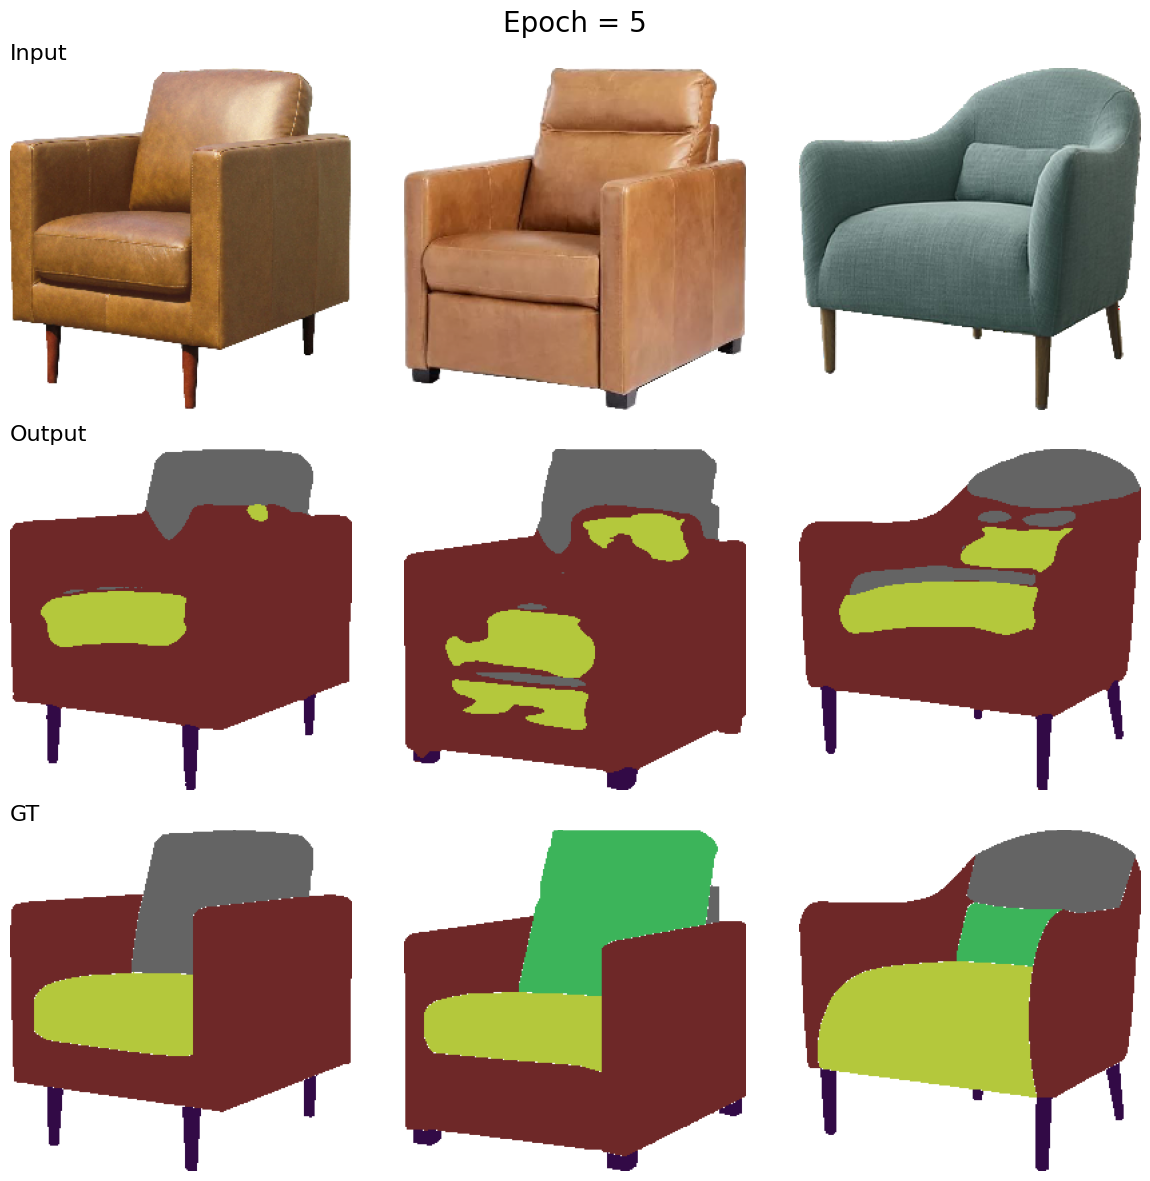

Epoch [6/20], Loss: 0.5930
Epoch [7/20], Loss: 0.5506
Epoch [8/20], Loss: 0.5122
Epoch [9/20], Loss: 0.4922
Epoch [10/20], Loss: 0.4592


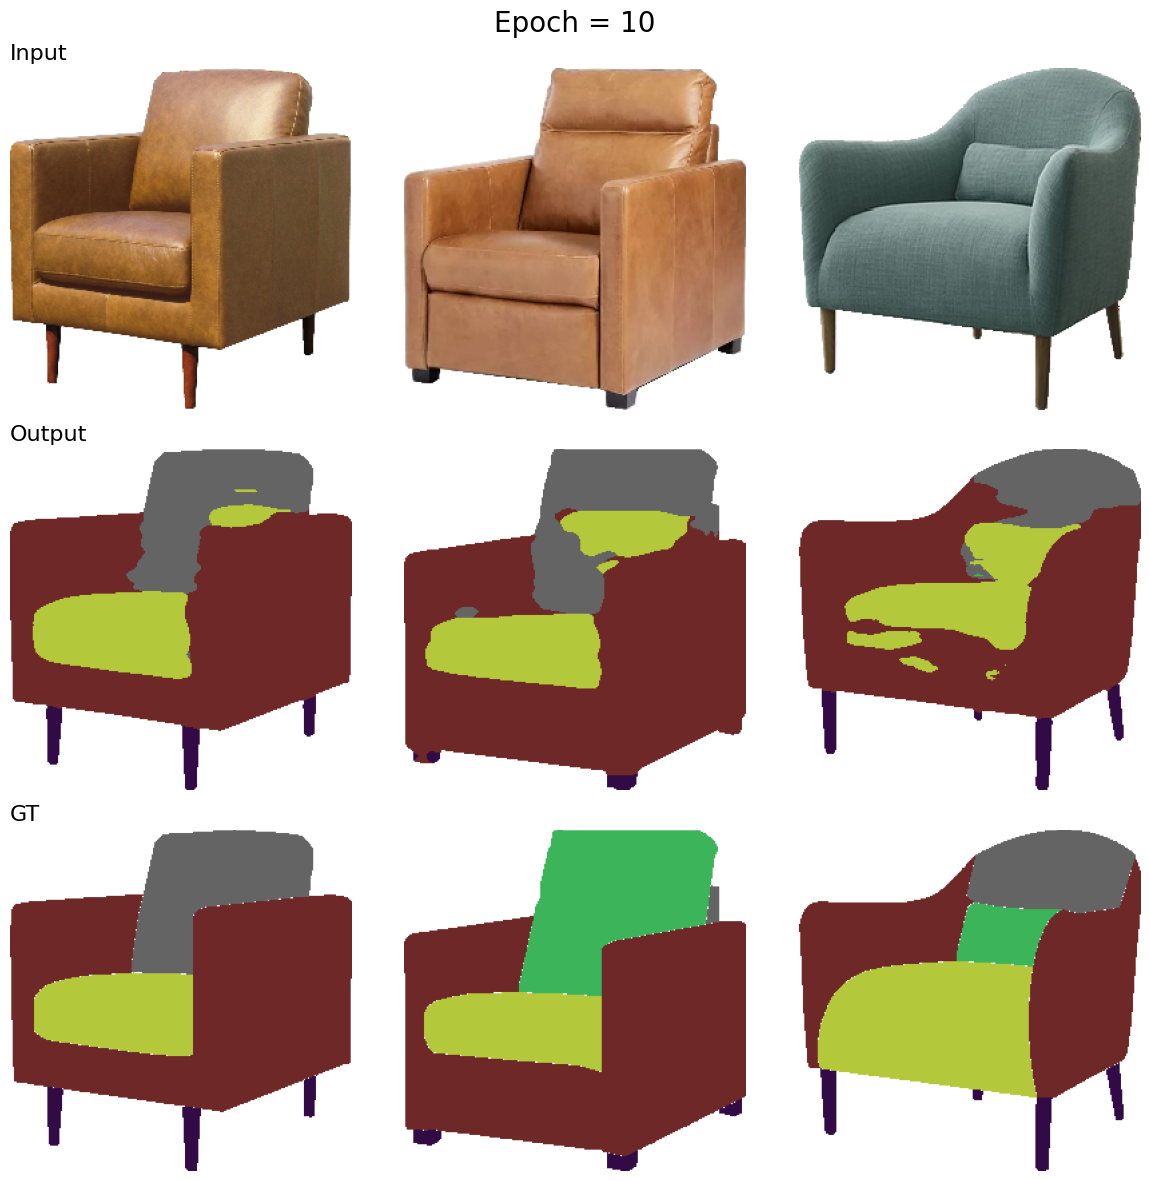

Epoch [11/20], Loss: 0.4453
Epoch [12/20], Loss: 0.4185
Epoch [13/20], Loss: 0.4026
Epoch [14/20], Loss: 0.4054
Epoch [15/20], Loss: 0.3992
Epoch [16/20], Loss: 0.3885
Epoch [17/20], Loss: 0.3864
Epoch [18/20], Loss: 0.3640
Epoch [19/20], Loss: 0.3553
Epoch [20/20], Loss: 0.3374


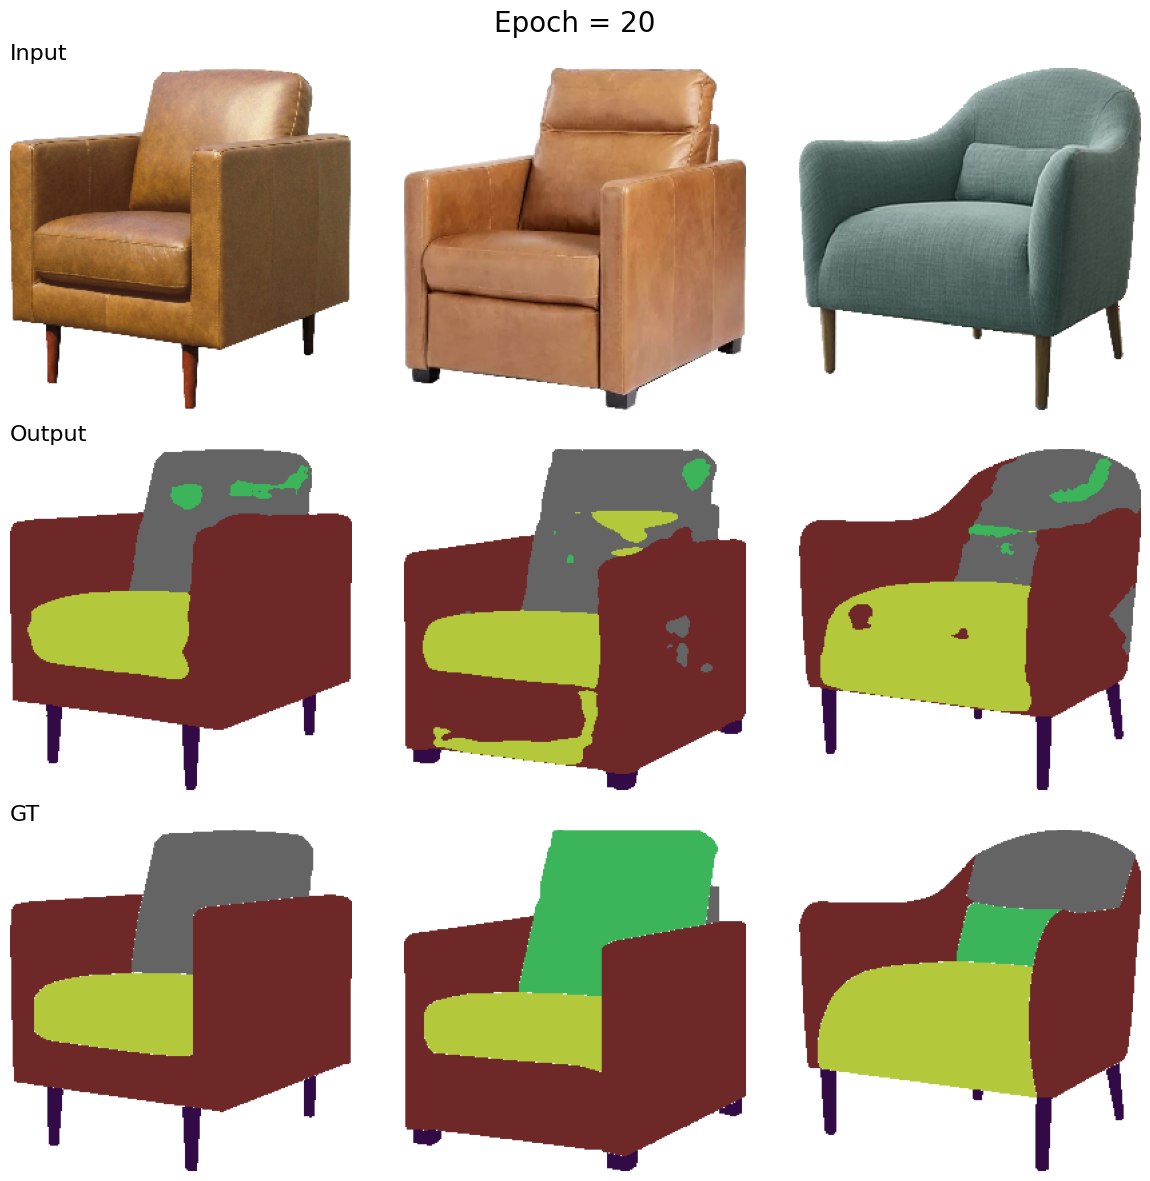

In [5]:
import random

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch}/{EPOCHS}], Loss: {epoch_loss/len(train_loader):.4f}")

    # 在 Epoch 5, 10, 20 繪製 Validation 結果
    if epoch in [5, 10, 20]:
        model.eval()
        with torch.no_grad():
            # 取出 3 張驗證集圖片
            val_images, val_masks = next(iter(val_loader))
            val_images, val_masks = val_images.to(DEVICE), val_masks.to(DEVICE)

            outputs = model(val_images)
            preds = torch.argmax(outputs, dim=1)

            # 建立 3x3 的畫布 (Row: Input, Output, GT; Col: 3 張不同的圖)
            fig, axes = plt.subplots(3, 3, figsize=(12, 12))

            for i in range(3):
                img_show = val_images[i].cpu().permute(1, 2, 0).numpy()
                gt_show = mask_to_rgb(val_masks[i].cpu().numpy())
                pred_show = mask_to_rgb(preds[i].cpu().numpy())

                # Input
                axes[0, i].imshow(img_show)
                axes[0, i].axis('off')
                if i == 0: axes[0, i].set_title("Input", fontsize=16, loc='left')

                # Output (Prediction)
                axes[1, i].imshow(pred_show)
                axes[1, i].axis('off')
                if i == 0: axes[1, i].set_title("Output", fontsize=16, loc='left')

                # GT (Ground Truth)
                axes[2, i].imshow(gt_show)
                axes[2, i].axis('off')
                if i == 0: axes[2, i].set_title("GT", fontsize=16, loc='left')

            plt.suptitle(f'Epoch = {epoch}', fontsize=20)
            plt.tight_layout()
            plt.show()

In [6]:
# --- 測試集預測與存檔 ---
test_dataset = SofaDataset(TEST_IMG_DIR, mask_dir=None, img_size=IMAGE_SIZE)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()
with torch.no_grad():
    for images, img_names in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()[0]

        pred_rgb = mask_to_rgb(preds)
        pred_bgr = cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(PREDICT_DIR, img_names[0].replace('.png', '_predict.png'))
        cv2.imwrite(save_path, pred_bgr)
        print(f"Result saved: {save_path}")

print("All test images have been done.")

Result saved: /content/drive/MyDrive/data/test/predict/0401_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0402_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0403_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0404_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0405_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0406_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0407_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0408_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0409_predict.png
Result saved: /content/drive/MyDrive/data/test/predict/0410_predict.png
All test images have been done.


[25] PSNR: 37.69
IoU: 椅墊: 13.02%, 扶手: 94.29%, 椅腳: 86.01%, 椅子底: 92.04%, 椅背: 2.53%


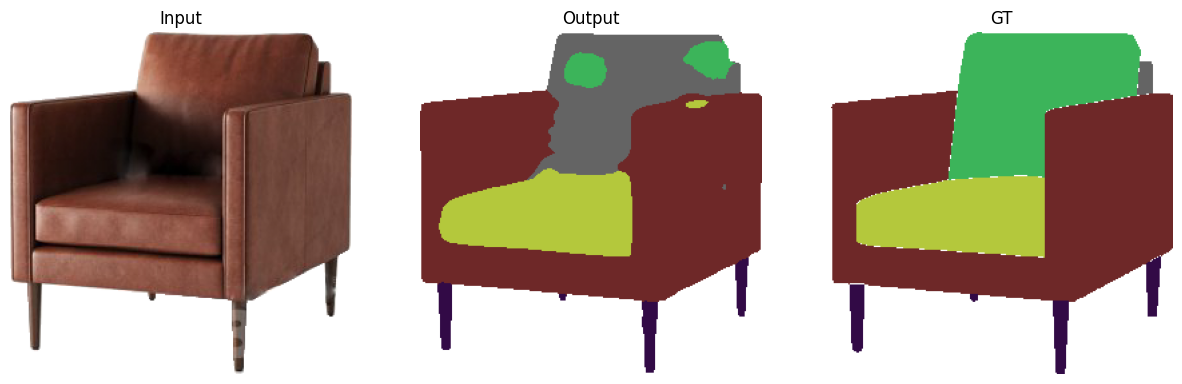

In [16]:
import math

# 從validation set隨機抽樣一張進行評估 (Slide 11-13)
model.eval()
with torch.no_grad():

    val_dataset_list = list(val_dataset)
    ix = random.randint(0, len(val_dataset_list) - 1)

    src_image, tar_mask = val_dataset_list[ix]
    src_image_batch = src_image.unsqueeze(0).to(DEVICE)

    outputs = model(src_image_batch)
    gen_mask = torch.argmax(outputs, dim=1)[0].cpu()

    gen_image_rgb = mask_to_rgb(gen_mask.numpy())
    tar_image_rgb = mask_to_rgb(tar_mask.numpy())

    psnr_val = calculate_psnr(gen_image_rgb, tar_image_rgb)

    # 計算此張圖片的各類別 IoU
    ious, _ = calculate_iou(gen_mask, tar_mask, NUM_CLASSES)

    print(f"[{ix}] PSNR: {psnr_val:.2f}")
    iou_str_list = []
    for cls_idx, iou_val in enumerate(ious, start=1):
        if not np.isnan(iou_val): # 只有圖片中真實存在的部位才印出來
            iou_str_list.append(f"{CLASS_NAMES[cls_idx]}: {iou_val*100:.2f}%")
    print("IoU: " + ", ".join(iou_str_list))

    # 畫出這張圖片
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(src_image.permute(1, 2, 0).numpy())
    ax[0].set_title('Input')
    ax[0].axis('off')
    ax[1].imshow(gen_image_rgb)
    ax[1].set_title('Output')
    ax[1].axis('off')
    ax[2].imshow(tar_image_rgb)
    ax[2].set_title('GT')
    ax[2].axis('off')
    plt.show()



In [8]:
# 測試集整體平均 IoU 計算 (Slide 14-16)
print("\n" + "="*30)
print("Overall Result")
print("="*30)

# 用來累加每個類別的 iou 總和與計算次數
iou_sums = {cls: 0.0 for cls in range(1, NUM_CLASSES)}
iou_counts = {cls: 0 for cls in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, masks in DataLoader(val_dataset, batch_size=1):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # 針對這張圖片計算 IoU
        ious, _ = calculate_iou(preds[0], masks[0], NUM_CLASSES)

        # 累加分數
        for cls_idx, iou_val in enumerate(ious, start=1):
            if not np.isnan(iou_val): # 若這張圖片有這個部位，才納入平均計算
                iou_sums[cls_idx] += iou_val
                iou_counts[cls_idx] += 1

# 計算平均並印出
overall_iou_sum = 0
valid_classes = 0

for cls in range(1, NUM_CLASSES):
    if iou_counts[cls] > 0:
        avg_iou = iou_sums[cls] / iou_counts[cls]
        overall_iou_sum += avg_iou
        valid_classes += 1
        print(f"• {CLASS_NAMES[cls]}: {avg_iou*100:.2f}%")
    else:
        print(f"• {CLASS_NAMES[cls]}: N/A (測試圖中未出現)")

if valid_classes > 0:
    overall_miou = overall_iou_sum / valid_classes
    print(f"\nOverall IoU: {overall_miou*100:.2f}%")


Overall Result
• 椅墊: 3.36%
• 扶手: 80.11%
• 椅腳: 79.04%
• 椅子底: 77.44%
• 椅背: 51.90%

Overall IoU: 58.37%
